# 🚀 Part 3: Transfer Learning & Model Training

**Author:** [Dominikus Krisna Herlambang](https://www.linkedin.com/in/dominikus-krisna-herlambang)<br>
**Date created:** 2021<br>
**Last modified:** 2021<br>

## 🔧 Section 1: Setup & Environment

In [ ]:
# Check GPU availability
import torch

print("🖥️ GPU Info:")
if torch.cuda.is_available():
    print(f"   ✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   CUDA Version: {torch.version.cuda}")
else:
    print("   ⚠️ No GPU available. Training will be slow!")
    print("   💡 Enable GPU: Runtime > Change runtime type > GPU")

🖥️ GPU Info:
   ✅ GPU available: Tesla T4
   Memory: 15.83 GB
   CUDA Version: 12.6


In [ ]:
# Install required packages (if needed)
!pip install -q torch torchvision tqdm scikit-learn seaborn

print("✅ Packages installed!")

✅ Packages installed!


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm.auto import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Using device: {device}")

# Set seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
np.random.seed(42)

print("✅ Setup complete!")


🖥️ Using device: cuda
✅ Setup complete!


---
## 📚 Section 2: Understanding Transfer Learning

### 🤔 What is Transfer Learning?

**Simple Analogy:**
> Like learning Spanish when you already know English
> - Don't start from scratch
> - Leverage existing knowledge (grammar, vocabulary)
> - Focus only on differences

**In Deep Learning:**
- Use a model trained on ImageNet (1.4M images, 1000 classes)
- The model has learned general features: edges, textures, shapes, objects
- We only train the last layer for our specific task

### ✅ Advantages of Transfer Learning:

| Aspek | From Scratch | Transfer Learning |
|-------|-------------|------------------|
| ⏱️ Training Time | 6-12 hours | **10-15 minutes** |
| 📊 Data Needed | 1000+ images/class | **50-100 images/class** |
| 💰 Cost | GPU expensive | **Free (Colab)** |
| 🔧 Complexity | High | **Low** |

### 📊 ResNet18 Architecture:
```
Input (224x224x3)
    ↓
Conv Layer 1 (64 filters)   ← Detect edges
    ↓
Conv Block 2-5 (Residual)   ← Detect textures, patterns
    ↓
Global Average Pooling      ← Summarize features
    ↓
Fully Connected (512→1000)  ← Classification
    ↓
Output (1000 classes)
```

**We will:**
1. ❄️ Freeze all layers except the last FC layer
2. 🔄 Replace FC: 512 → 10 (our classes)
3. 🚀 Train only ~1,500 parameters (vs 11M total!)
---

## 📦 Section 3: Data Preparation

In [ ]:
# Import libraries
import torch
import torchvision
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm.auto import tqdm
import shutil

print("📥 Downloading CIFAR-10...\n")
print("(This is a one-time download, ~170 MB)\n")

# Download CIFAR-10
train_dataset = datasets.CIFAR10(
    root='/content/cifar10_raw',
    train=True,
    download=True
)

test_dataset = datasets.CIFAR10(
    root='/content/cifar10_raw',
    train=False,
    download=True
)

print("\n✅ CIFAR-10 Downloaded!")
print(f"   Train: {len(train_dataset)} images")
print(f"   Test:  {len(test_dataset)} images")

# CIFAR-10 classes
cifar10_classes = [
    'airplane',    # 0
    'automobile',  # 1
    'bird',        # 2
    'cat',         # 3
    'deer',        # 4
    'dog',         # 5
    'frog',        # 6
    'horse',       # 7
    'ship',        # 8
    'truck'        # 9
]

print(f"\n📋 Classes: {cifar10_classes}")

📥 Downloading CIFAR-10...

(This is a one-time download, ~170 MB)



100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]



✅ CIFAR-10 Downloaded!
   Train: 50000 images
   Test:  10000 images

📋 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# OPSI 1: All 10 Classes
print("📦 Creating Full CIFAR-10 Dataset (10 classes)...\n")

OUTPUT_DIR = '/content/cifar10_dataset'

# Use all classes
selected_classes = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

print(f"✅ Selected classes: {list(selected_classes.values())}")
print(f"\n📍 Output directory: {OUTPUT_DIR}")
print("\n🚀 Organizing into train/val/test structure...\n")

# Function to organize dataset
def organize_cifar(dataset, output_dir, split_name, selected_classes, fraction=1.0, seed=42):
    """
    Organize CIFAR-10 into folder structure

    Args:
        dataset: CIFAR-10 dataset
        output_dir: Output directory
        split_name: 'train', 'val', or 'test'
        selected_classes: Dict of class_id: class_name
        fraction: Fraction of data to use (for train/val split)
        seed: Random seed
    """
    np.random.seed(seed)

    # Create directories
    for class_name in selected_classes.values():
        os.makedirs(os.path.join(output_dir, split_name, class_name), exist_ok=True)

    # Save images
    counts = {name: 0 for name in selected_classes.values()}

    for img, label in tqdm(dataset, desc=f"Processing {split_name}"):
        # Check if class is selected
        if label not in selected_classes:
            continue

        # Random sampling for train/val split
        if np.random.random() > fraction:
            continue

        class_name = selected_classes[label]

        # Save image
        img_path = os.path.join(
            output_dir, split_name, class_name,
            f"{class_name}_{counts[class_name]:05d}.png"
        )
        img.save(img_path)
        counts[class_name] += 1

    return counts

# Organize splits
# Train: 80% of train_dataset
print("Creating train split (80%)...")
train_counts = organize_cifar(
    train_dataset, OUTPUT_DIR, 'train', selected_classes, fraction=0.8, seed=42
)

# Val: 20% of train_dataset
print("\nCreating val split (20%)...")
val_counts = organize_cifar(
    train_dataset, OUTPUT_DIR, 'val', selected_classes, fraction=0.2, seed=43
)

# Test: All of test_dataset
print("\nCreating test split (100% of test set)...")
test_counts = organize_cifar(
    test_dataset, OUTPUT_DIR, 'test', selected_classes, fraction=1.0, seed=44
)

# Summary
print("\n" + "="*70)
print("✅ CIFAR-10 DATASET READY (10 CLASSES)")
print("="*70)
print(f"\n📂 Location: {OUTPUT_DIR}")
print(f"\n📊 Dataset Summary:")
print(f"\nTRAIN:")
for cls, count in train_counts.items():
    print(f"   {cls:<12} {count:>5} images")
print(f"   {'TOTAL':<12} {sum(train_counts.values()):>5} images")

print(f"\nVAL:")
for cls, count in val_counts.items():
    print(f"   {cls:<12} {count:>5} images")
print(f"   {'TOTAL':<12} {sum(val_counts.values()):>5} images")

print(f"\nTEST:")
for cls, count in test_counts.items():
    print(f"   {cls:<12} {count:>5} images")
print(f"   {'TOTAL':<12} {sum(test_counts.values()):>5} images")

total = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())
print(f"\n🎯 GRAND TOTAL: {total:,} images")

print("\n💡 Use this in your training code:")
print(f"   DATA_DIR = '{OUTPUT_DIR}'")

📦 Creating Full CIFAR-10 Dataset (10 classes)...

✅ Selected classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

📍 Output directory: /content/cifar10_dataset

🚀 Organizing into train/val/test structure...

Creating train split (80%)...


Processing train:   0%|          | 0/50000 [00:00<?, ?it/s]


Creating val split (20%)...


Processing val:   0%|          | 0/50000 [00:00<?, ?it/s]


Creating test split (100% of test set)...


Processing test:   0%|          | 0/10000 [00:00<?, ?it/s]


✅ CIFAR-10 DATASET READY (10 CLASSES)

📂 Location: /content/cifar10_dataset

📊 Dataset Summary:

TRAIN:
   airplane      3991 images
   automobile    3982 images
   bird          4040 images
   cat           4018 images
   deer          3967 images
   dog           4026 images
   frog          4027 images
   horse         4003 images
   ship          4017 images
   truck         4003 images
   TOTAL        40074 images

VAL:
   airplane       937 images
   automobile     988 images
   bird           932 images
   cat            996 images
   deer           967 images
   dog            937 images
   frog          1009 images
   horse         1001 images
   ship           971 images
   truck         1037 images
   TOTAL         9775 images

TEST:
   airplane      1000 images
   automobile    1000 images
   bird          1000 images
   cat           1000 images
   deer          1000 images
   dog           1000 images
   frog          1000 images
   horse         1000 images
   ship     

In [ ]:
!rm -rf /content/cifar10_dataset/

In [ ]:
!unzip -q /content/cifar10_dataset.zip -d /content/cifar10_dataset

In [ ]:
!rm -rf /content/cifar10_dataset/__MACOSX/

In [ ]:
# Data transforms - CRITICAL for transfer learning!
# Must use ImageNet normalization stats

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),           # Resize to 256
        transforms.RandomCrop(224),              # Random crop to 224 (data aug)
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance flip
        transforms.RandomRotation(degrees=30),   # Rotate ±30°
        transforms.ColorJitter(
            brightness=0.2,                      # Brightness variation
            contrast=0.2,                        # Contrast variation
            saturation=0.2,                      # Saturation variation
            hue=0.1                              # Hue variation
        ),
        transforms.ToTensor(),                   # Convert to tensor
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],         # ImageNet mean (REQUIRED!)
            std=[0.229, 0.224, 0.225]           # ImageNet std (REQUIRED!)
        )
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),           # Resize to 224 (NO crop)
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),           # Same as validation
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
}

print("✅ Transforms defined!")
print("\n📝 Key Points:")
print("   - Training: 5 augmentations applied")
print("   - Val/Test: NO augmentation (only resize + normalize)")
print("   - ImageNet normalization MUST be used for pretrained models!")

✅ Transforms defined!

📝 Key Points:
   - Training: 5 augmentations applied
   - Val/Test: NO augmentation (only resize + normalize)
   - ImageNet normalization MUST be used for pretrained models!


In [ ]:
DATA_DIR = '/content/cifar10_dataset/cifar10_dataset'

# Create datasets
image_datasets = {
    x: datasets.ImageFolder(
        root=os.path.join(DATA_DIR, x),
        transform=data_transforms[x]
    )
    for x in ['train', 'val', 'test']
}

# Create dataloaders
dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=32,
        shuffle=(x == 'train'),  # Shuffle only training data
        num_workers=0,           # Parallel loading
        pin_memory=True          # Faster GPU transfer
    )
    for x in ['train', 'val', 'test']
}

# Dataset info
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print("📊 Dataset Info:")
print(f"   Classes: {class_names}")
print(f"   Number of classes: {num_classes}")
print(f"\n   Train: {dataset_sizes['train']} images")
print(f"   Val:   {dataset_sizes['val']} images")
print(f"   Test:  {dataset_sizes['test']} images")
print(f"\n✅ Dataloaders ready!")

# Verify data distribution
print("\n📈 Data Distribution Check:")
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}:")
    for i, cls in enumerate(class_names):
        count = sum(1 for _, label in image_datasets[split] if label == i)
        print(f"   {cls}: {count} images")

📊 Dataset Info:
   Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
   Number of classes: 10

   Train: 1000 images
   Val:   200 images
   Test:  100 images

✅ Dataloaders ready!

📈 Data Distribution Check:

TRAIN:
   airplane: 100 images
   automobile: 100 images
   bird: 100 images
   cat: 100 images
   deer: 100 images
   dog: 100 images
   frog: 100 images
   horse: 100 images
   ship: 100 images
   truck: 100 images

VAL:
   airplane: 20 images
   automobile: 20 images
   bird: 20 images
   cat: 20 images
   deer: 20 images
   dog: 20 images
   frog: 20 images
   horse: 20 images
   ship: 20 images
   truck: 20 images

TEST:
   airplane: 10 images
   automobile: 10 images
   bird: 10 images
   cat: 10 images
   deer: 10 images
   dog: 10 images
   frog: 10 images
   horse: 10 images
   ship: 10 images
   truck: 10 images


---
## 🧠 Section 4: Load Pre-trained Model

We'll use **ResNet18** - a powerful CNN architecture with 50 layers

In [ ]:
# Load pre-trained ResNet18
print("📥 Loading pre-trained ResNet18...")
print("   (This will download ~44MB if first time)\n")

model = models.resnet18(pretrained=True)

print("✅ Model loaded!\n")
print("📊 Model Statistics:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"\n🔍 Final Layer Info:")
print(f"   Current: {model.fc}")

📥 Loading pre-trained ResNet18...
   (This will download ~44MB if first time)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]

✅ Model loaded!

📊 Model Statistics:
   Total parameters: 11,689,512
   Trainable parameters: 11,689,512

🔍 Final Layer Info:
   Current: Linear(in_features=512, out_features=1000, bias=True)


### 🔧 Modify Model for Our Task

**Strategy:**
1. ❄️ Freeze all convolutional layers (keep learned features)
2. 🔄 Replace final FC layer (1000 classes → 3 classes)
3. 🚀 Train only the new FC layer

In [ ]:
# Step 1: Freeze all layers
print("❄️ Freezing all layers...")
for param in model.parameters():
    param.requires_grad = False

# Step 2: Replace final layer
num_features = model.fc.in_features  # 512 for ResNet18
model.fc = nn.Linear(num_features, num_classes)

print(f"\n🔄 Replaced final layer:")
print(f"   Input features: {num_features}")
print(f"   Output classes: {num_classes}")
print(f"   New layer: {model.fc}")

# Step 3: Move model to device
model = model.to(device)

# Verify trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Updated Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Frozen parameters: {total_params - trainable_params:,}")
print(f"   Percentage trainable: {100 * trainable_params / total_params:.4f}%")

print(f"\n🖥️ Model moved to: {device}")
print("✅ Model ready for training!")

print("\n💡 Key Insight:")
print(f"   We're only training {trainable_params:,} parameters")
print(f"   instead of {total_params:,} - that's why it's fast!")

❄️ Freezing all layers...

🔄 Replaced final layer:
   Input features: 512
   Output classes: 10
   New layer: Linear(in_features=512, out_features=10, bias=True)

📊 Updated Model Statistics:
   Total parameters: 11,181,642
   Trainable parameters: 5,130
   Frozen parameters: 11,176,512
   Percentage trainable: 0.0459%

🖥️ Model moved to: cuda
✅ Model ready for training!

💡 Key Insight:
   We're only training 5,130 parameters
   instead of 11,181,642 - that's why it's fast!


---
## 🎯 Section 5: Training Setup

Define loss function, optimizer, and learning rate scheduler

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - only train final layer parameters
optimizer = optim.Adam(
    model.fc.parameters(),  # Only FC layer
    lr=0.001,              # Learning rate
    weight_decay=1e-4      # L2 regularization
)

# Learning rate scheduler
# Reduces LR by factor of 0.1 every 7 epochs
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

print("✅ Training setup complete!")
print(f"\n📝 Configuration:")
print(f"   Loss Function: CrossEntropyLoss")
print(f"   Optimizer: Adam")
print(f"   Learning Rate: 0.001")
print(f"   Weight Decay: 1e-4 (L2 regularization)")
print(f"   LR Scheduler: StepLR")
print(f"     - Reduce LR every 7 epochs")
print(f"     - Reduction factor: 0.1")
print(f"     - Schedule: 0.001 → 0.0001 → 0.00001")

✅ Training setup complete!

📝 Configuration:
   Loss Function: CrossEntropyLoss
   Optimizer: Adam
   Learning Rate: 0.001
   Weight Decay: 1e-4 (L2 regularization)
   LR Scheduler: StepLR
     - Reduce LR every 7 epochs
     - Reduction factor: 0.1
     - Schedule: 0.001 → 0.0001 → 0.00001


---
## 🚀 Section 6: Training Loop

The magic happens here!

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    """
    Train the model with comprehensive monitoring

    Args:
        model: PyTorch model
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of epochs

    Returns:
        model: Trained model
        history: Training history dict
    """
    since = time.time()

    # Initialize history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []  # Track learning rate
    }

    # Best model tracking
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print("🚀 Starting training...\n")
    print("="*70)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 70)

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Learning Rate: {current_lr:.6f}")

        # Each epoch has training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Progress bar
            pbar = tqdm(
                dataloaders[phase],
                desc=f"{phase.capitalize()}",
                leave=False
            )

            # Iterate over data
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                # Track gradient only in training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only in training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar
                current_acc = (torch.sum(preds == labels.data).double() / inputs.size(0)).item()
                pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'acc': f"{current_acc:.4f}"
                })

            # Update learning rate (only after train phase)
            if phase == 'train':
                scheduler.step()

            # Calculate epoch metrics
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Save to history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # Print epoch results
            print(f"{phase.capitalize():5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Deep copy the best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"✨ New best model! Acc: {best_acc:.4f}")

    # Training complete
    time_elapsed = time.time() - since
    print("\n" + "="*70)
    print(f"\n✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"🏆 Best val accuracy: {best_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
# Train the model
NUM_EPOCHS = 10  # Adjust as needed (10-15 epochs usually enough)

print(f"⏰ Estimated training time: {NUM_EPOCHS * 1.5:.0f}-{NUM_EPOCHS * 2:.0f} minutes")
print(f"💡 Go get a coffee! ☕\n")

model, history = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS
)

⏰ Estimated training time: 15-20 minutes
💡 Go get a coffee! ☕

🚀 Starting training...


Epoch 1/10
----------------------------------------------------------------------
Learning Rate: 0.001000


Train:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 2.1974 Acc: 0.2040


Val:   0%|          | 0/7 [00:00<?, ?it/s]

Val   Loss: 1.9179 Acc: 0.3350
✨ New best model! Acc: 0.3350

Epoch 2/10
----------------------------------------------------------------------
Learning Rate: 0.001000


...

Val   Loss: 1.1103 Acc: 0.6700
✨ New best model! Acc: 0.6700

Epoch 10/10
----------------------------------------------------------------------
Learning Rate: 0.000100


Train:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 1.2769 Acc: 0.6010


Val:   0%|          | 0/7 [00:00<?, ?it/s]

Val   Loss: 1.1097 Acc: 0.6450


✅ Training complete in 1m 34s
🏆 Best val accuracy: 0.6700


---
## 📊 Section 7: Visualize Training

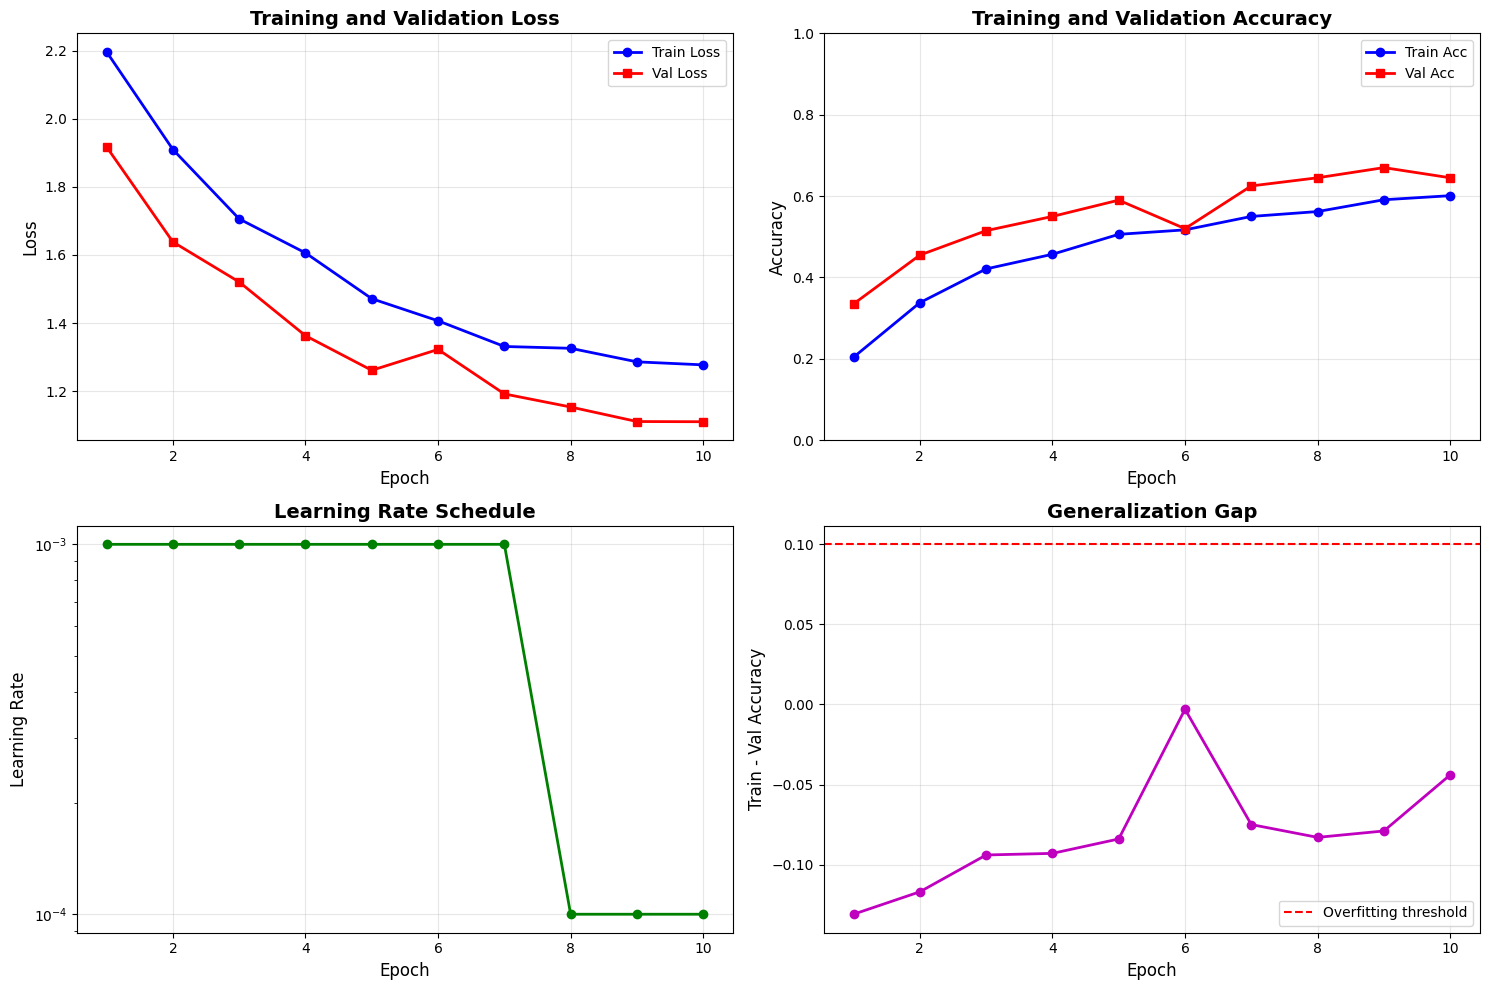


📊 Final Metrics:
Train Loss: 1.2769
Train Acc:  0.6010 (60.10%)
Val Loss:   1.1097
Val Acc:    0.6450 (64.50%)

Accuracy Gap: -0.0440 (-4.40%)

✅ Excellent generalization!
   Model generalizes well to unseen data

🏆 Best validation accuracy: 0.6700 at epoch 9


In [ ]:
def plot_training_history(history):
    """
    Plot comprehensive training curves
    """
    epochs = range(1, len(history['train_loss']) + 1)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Loss curves
    ax1 = axes[0, 0]
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
    ax1.plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Accuracy curves
    ax2 = axes[0, 1]
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=6)
    ax2.plot(epochs, history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])

    # 3. Learning rate schedule
    ax3 = axes[1, 0]
    ax3.plot(epochs, history['lr'], 'g-o', linewidth=2, markersize=6)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Learning Rate', fontsize=12)
    ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')

    # 4. Train-Val Gap (Overfitting indicator)
    ax4 = axes[1, 1]
    acc_gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
    ax4.plot(epochs, acc_gap, 'm-o', linewidth=2, markersize=6)
    ax4.axhline(y=0.1, color='r', linestyle='--', label='Overfitting threshold')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Train - Val Accuracy', fontsize=12)
    ax4.set_title('Generalization Gap', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    print("\n📊 Final Metrics:")
    print("="*50)
    print(f"Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"Train Acc:  {history['train_acc'][-1]:.4f} ({history['train_acc'][-1]*100:.2f}%)")
    print(f"Val Loss:   {history['val_loss'][-1]:.4f}")
    print(f"Val Acc:    {history['val_acc'][-1]:.4f} ({history['val_acc'][-1]*100:.2f}%)")

    # Overfitting analysis
    train_acc = history['train_acc'][-1]
    val_acc = history['val_acc'][-1]
    gap = train_acc - val_acc

    print(f"\nAccuracy Gap: {gap:.4f} ({gap*100:.2f}%)")
    print("="*50)

    if gap > 0.1:
        print("\n⚠️ Model is overfitting!")
        print("💡 Solutions:")
        print("   1. Add more training data")
        print("   2. Increase data augmentation")
        print("   3. Add dropout or regularization")
        print("   4. Early stopping")
    elif gap > 0.05:
        print("\n⚠️ Slight overfitting")
        print("💡 Monitor closely, consider slight regularization")
    else:
        print("\n✅ Excellent generalization!")
        print("   Model generalizes well to unseen data")

    # Best epoch
    best_epoch = np.argmax(history['val_acc']) + 1
    best_val_acc = max(history['val_acc'])
    print(f"\n🏆 Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

# Plot training history
plot_training_history(history)

---
## 🎯 Section 8: Test Set Evaluation

In [ ]:
def evaluate_model(model, test_loader, class_names, device):
    """
    Comprehensive model evaluation on test set
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    print("🔍 Evaluating on test set...\n")

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate overall accuracy
    accuracy = np.mean(all_preds == all_labels)

    print("\n" + "="*70)
    print(f"\n🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\n" + "="*70)

    # Per-class performance
    print("\n📊 Per-Class Performance:")
    print("-" * 60)
    print(f"{'Class':<15} {'Accuracy':<10} {'Count':<10} {'Avg Confidence'}")
    print("-" * 60)

    for i, class_name in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            class_acc = np.mean(all_preds[mask] == all_labels[mask])
            class_count = mask.sum()
            avg_conf = np.mean(all_probs[mask, i])
            print(f"{class_name:<15} {class_acc:.4f}     {class_count:<10} {avg_conf:.4f}")

    return all_preds, all_labels, all_probs

# Evaluate model
preds, labels, probs = evaluate_model(model, dataloaders['test'], class_names, device)

🔍 Evaluating on test set...



Testing:   0%|          | 0/4 [00:00<?, ?it/s]



🎯 Test Accuracy: 0.5600 (56.00%)


📊 Per-Class Performance:
------------------------------------------------------------
Class           Accuracy   Count      Avg Confidence
------------------------------------------------------------
airplane        0.9000     10         0.3532
automobile      0.8000     10         0.6666
bird            0.2000     10         0.2061
cat             0.1000     10         0.1483
deer            0.4000     10         0.2398
dog             0.6000     10         0.3146
frog            0.9000     10         0.6465
horse           0.6000     10         0.4261
ship            0.5000     10         0.3034
truck           0.6000     10         0.4474


### 📈 Confusion Matrix & Classification Report

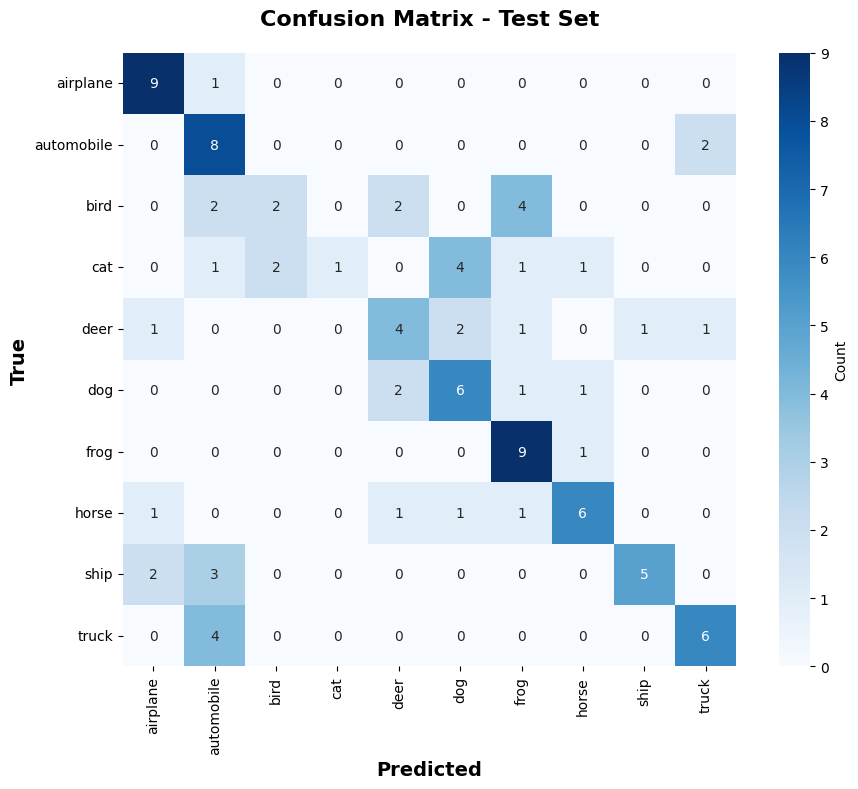


📝 Detailed Classification Report:
              precision    recall  f1-score   support

    airplane     0.6923    0.9000    0.7826        10
  automobile     0.4211    0.8000    0.5517        10
        bird     0.5000    0.2000    0.2857        10
         cat     1.0000    0.1000    0.1818        10
        deer     0.4444    0.4000    0.4211        10
         dog     0.4615    0.6000    0.5217        10
        frog     0.5294    0.9000    0.6667        10
       horse     0.6667    0.6000    0.6316        10
        ship     0.8333    0.5000    0.6250        10
       truck     0.6667    0.6000    0.6316        10

    accuracy                         0.5600       100
   macro avg     0.6215    0.5600    0.5299       100
weighted avg     0.6215    0.5600    0.5299       100


💡 Insights:
----------------------------------------------------------------------
Most confused classes:
   bird → frog
   Count: 4 misclassifications


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(labels, preds)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'},
    square=True
)
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.ylabel('True', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Classification report
print("\n📝 Detailed Classification Report:")
print("="*70)
print(classification_report(
    labels,
    preds,
    target_names=class_names,
    digits=4
))

# Additional insights
print("\n💡 Insights:")
print("-" * 70)

# Find most confused pairs
np.fill_diagonal(cm, 0)
max_confusion = np.unravel_index(cm.argmax(), cm.shape)
if cm[max_confusion] > 0:
    print(f"Most confused classes:")
    print(f"   {class_names[max_confusion[0]]} → {class_names[max_confusion[1]]}")
    print(f"   Count: {cm[max_confusion]} misclassifications")
else:
    print("✅ Perfect classification! No confusion between classes.")

---
## 💾 Section 9: Save Model

In [ ]:
# Save model with comprehensive metadata
MODEL_PATH = '/content/cifar10_resnet18.pth'

# Create checkpoint
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'history': history,
    'best_val_acc': max(history['val_acc']),
    'test_acc': np.mean(preds == labels),
    'architecture': 'ResNet18',
    'input_size': (224, 224),
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    }
}

# Save
torch.save(checkpoint, MODEL_PATH)

print(f"✅ Model saved to: {MODEL_PATH}")
print(f"📦 File size: {os.path.getsize(MODEL_PATH) / 1e6:.2f} MB")

print("\n📋 Checkpoint contains:")
print("   ✓ Model weights")
print("   ✓ Optimizer state")
print("   ✓ Scheduler state")
print("   ✓ Class names")
print("   ✓ Training history")
print("   ✓ Best validation accuracy")
print("   ✓ Test accuracy")
print("   ✓ Architecture info")
print("   ✓ Preprocessing params")

# Download model
from google.colab import files

print("\n📥 Downloading model...")
files.download(MODEL_PATH)
print("✅ Download complete!")

✅ Model saved to: /content/cifar10_resnet18.pth
📦 File size: 44.85 MB

📋 Checkpoint contains:
   ✓ Model weights
   ✓ Optimizer state
   ✓ Scheduler state
   ✓ Class names
   ✓ Training history
   ✓ Best validation accuracy
   ✓ Test accuracy
   ✓ Architecture info
   ✓ Preprocessing params

📥 Downloading model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete!


### 🔄 Load Saved Model (for future use)

In [ ]:
def load_trained_model(model_path, device):
    """
    Load trained model from checkpoint

    Args:
        model_path: Path to .pth file
        device: torch device

    Returns:
        model: Loaded model
        checkpoint: Full checkpoint dict
    """
    print(f"📥 Loading model from: {model_path}")

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Get model info
    num_classes = checkpoint['num_classes']
    class_names = checkpoint['class_names']

    # Create model architecture
    model = models.resnet18(pretrained=False)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print("✅ Model loaded successfully!\n")
    print("📊 Model Info:")
    print(f"   Architecture: {checkpoint.get('architecture', 'ResNet18')}")
    print(f"   Classes: {class_names}")
    print(f"   Number of classes: {num_classes}")
    print(f"   Trained for: {checkpoint['epoch']} epochs")
    print(f"   Best val accuracy: {checkpoint.get('best_val_acc', 'N/A'):.4f}")
    print(f"   Test accuracy: {checkpoint.get('test_acc', 'N/A'):.4f}")

    return model, checkpoint

# Example: Load model
# loaded_model, loaded_checkpoint = load_trained_model(MODEL_PATH, device)

---
## 🖼️ Section 10: Test with New Images

📤 Upload an image to test...


Saving 20250329205944list_mobil_daihatsu_bekas.webp to 20250329205944list_mobil_daihatsu_bekas.webp


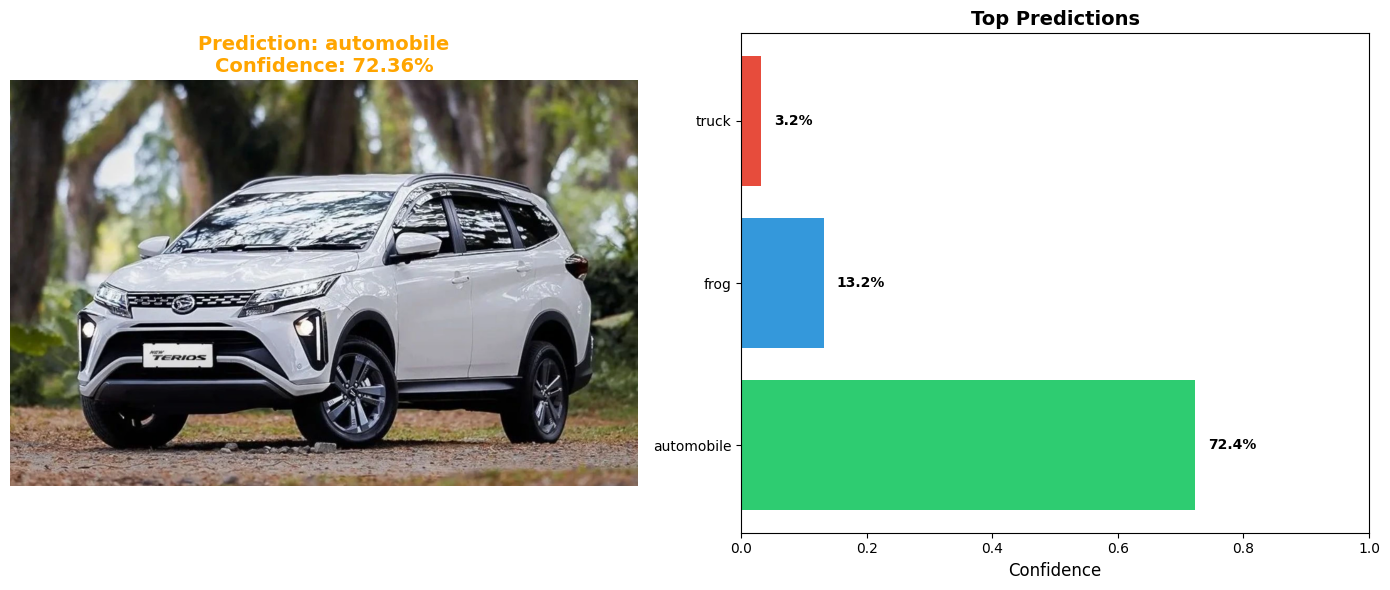


🎯 Prediction Results

🏆 Predicted Class: automobile
📊 Confidence: 72.36%

📋 Top 3 Predictions:
   1. automobile      72.36%
   2. frog            13.16%
   3. truck           3.23%

💡 Confidence Interpretation:
   ✅ Confident - Good prediction


In [ ]:
def predict_image(model, image_path, class_names, transform, device):
    """
    Predict single image with visualization
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    pred_class = class_names[predicted.item()]
    confidence = confidence.item()

    # Get top 3 predictions
    top3_probs, top3_indices = torch.topk(probs, min(3, len(class_names)))
    top3_probs = top3_probs[0].cpu().numpy()
    top3_indices = top3_indices[0].cpu().numpy()
    top3_classes = [class_names[i] for i in top3_indices]

    return pred_class, confidence, top3_classes, top3_probs, image

# Upload and test
print("📤 Upload an image to test...")
uploaded = files.upload()

if uploaded:
    test_image_path = list(uploaded.keys())[0]

    # Predict
    pred_class, confidence, top3_classes, top3_probs, image = predict_image(
        model=model,
        image_path=test_image_path,
        class_names=class_names,
        transform=data_transforms['test'],
        device=device
    )

    # Visualize results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Image with prediction
    ax1.imshow(image)
    confidence_color = 'green' if confidence > 0.8 else 'orange' if confidence > 0.5 else 'red'
    ax1.set_title(
        f"Prediction: {pred_class}\nConfidence: {confidence:.2%}",
        fontsize=14,
        fontweight='bold',
        color=confidence_color
    )
    ax1.axis('off')

    # Top 3 predictions bar chart
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    ax2.barh(range(len(top3_classes)), top3_probs, color=colors[:len(top3_classes)])
    ax2.set_yticks(range(len(top3_classes)))
    ax2.set_yticklabels(top3_classes)
    ax2.set_xlabel('Confidence', fontsize=12)
    ax2.set_title('Top Predictions', fontsize=14, fontweight='bold')
    ax2.set_xlim([0, 1])

    # Add percentage labels
    for i, prob in enumerate(top3_probs):
        ax2.text(prob + 0.02, i, f"{prob:.1%}", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\n" + "="*60)
    print("🎯 Prediction Results")
    print("="*60)
    print(f"\n🏆 Predicted Class: {pred_class}")
    print(f"📊 Confidence: {confidence:.2%}")

    print(f"\n📋 Top {len(top3_classes)} Predictions:")
    for i, (cls, prob) in enumerate(zip(top3_classes, top3_probs), 1):
        print(f"   {i}. {cls:<15} {prob:.2%}")

    # Confidence interpretation
    print("\n💡 Confidence Interpretation:")
    if confidence > 0.9:
        print("   ✅ Very confident - Excellent prediction!")
    elif confidence > 0.7:
        print("   ✅ Confident - Good prediction")
    elif confidence > 0.5:
        print("   ⚠️ Moderate confidence - Check alternatives")
    else:
        print("   ⚠️ Low confidence - Model is uncertain")

    print("="*60)